In [2]:
import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *
from syn_project.utils_notebook import *

import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

%matplotlib widget


In [3]:
condition = "3mod_basic_s126"
checkpoint_epoch = 0
n_samples_test = 1000
split = "test"


In [4]:
from typing import NamedTuple


class ModuleDataOutputs(NamedTuple):
    global_workspace: torch.Tensor
    domain_mods: list
    gw_mod: torch.nn.Module
    visual_module: torch.nn.Module
    original_colors: torch.Tensor
    original_attr: torch.Tensor
    original_v_latents: torch.Tensor
    cat: int
    latent_domains: dict
    
def get_modules_data_from_exp(experiment_name, n_samples_test=100, split='test', checkpoint_epoch=0):

    modules = get_setup_modules('syn', experiment_name)
    global_workspace = get_global_workspace("syn", experiment_name, epoch=checkpoint_epoch, modules=modules)
    data_module = get_data_module("syn",  experiment_name, modules=modules)

    test_samples = get_data_samples(data_module, n_samples_test, split=split)
    original_colors = test_samples[frozenset({'color', 'attr', 'v_latents'})]['color']
    original_attr = test_samples[frozenset({'color', 'attr', 'v_latents'})]['attr']
    original_v_latents = test_samples[frozenset({'color', 'attr', 'v_latents'})]['v_latents']
    cat = original_attr[0]

    domain_mods = global_workspace.domain_mods
    gw_mod = global_workspace.gw_mod
    latent_domains = global_workspace.encode_domains(test_samples)

    visual_module = cast(VisualLatentDomainModule, global_workspace.domain_mods["v_latents"])

    return ModuleDataOutputs(
        global_workspace=global_workspace,
        domain_mods=domain_mods,
        gw_mod=gw_mod,
        visual_module=visual_module,
        original_colors=original_colors,
        original_attr=original_attr,
        original_v_latents=original_v_latents,
        cat=cat,
        latent_domains=latent_domains
    )   




In [5]:
experiment_name = get_experiment_name(condition, "biased_00", 0)
global_workspace, domain_mods, gw_mod, visual_module, original_colors, original_attr, original_v_latents, cat, latent_domains = get_modules_data_from_exp(experiment_name=experiment_name, n_samples_test=n_samples_test, split=split, checkpoint_epoch=checkpoint_epoch)


/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
/home/luc

Loading model from checkpoint: /home/lucas/gwsyn/checkpoints/syn/3mod_basic_s126_biased_00/checkpoints/last.ckpt
Loaded default weights from /home/lucas/gwsyn/checkpoints/syn/3mod_basic_s126_biased_00/checkpoints/last.ckpt


In [6]:
latents_source = latent_domains[frozenset({'v_latents', 'attr', 'color'})]

    # à partir des latents vision, j'encode les représentations dans le gw
z_spatial = gw_mod.encode(latents_source)['v_latents']
z_couleur = gw_mod.encode(latents_source)['v_latents']

z_vision_2 = 0.5*z_spatial + 0.5*z_couleur
t = gw_mod.decode(z_vision_2, domains={'v_latents'})
vision2  = t['v_latents']

    #gw syn
color2 = gw_mod.decode(z_vision_2, domains={'color'})
gw_syn = gw_mod.encode(color2)['color']

In [7]:
color2

{'color': tensor([[0.7576, 0.9616, 0.9597],
         [0.0513, 0.9458, 0.9781],
         [0.6181, 0.6057, 0.9623],
         ...,
         [0.2426, 0.7964, 0.8755],
         [0.7758, 0.9709, 0.9863],
         [0.7303, 0.6787, 0.7667]], device='cuda:0', grad_fn=<SigmoidBackward0>)}

In [29]:
def get_objects_from_v_latents(latent_domains, gw_mod, global_workspace):
    latents_source_v_latents = latent_domains[frozenset({'v_latents'})]

    # à partir des latents vision, j'encode les représentations dans le gw
    z_input = gw_mod.encode(latents_source_v_latents)['v_latents']

    # je décode les attributs
    spatial = gw_mod.decode(z_input, domains={'attr'})

    # je les reformatte en attributs avec cat/autres séparés, puis je les re-encode dans la modalité attr correctement
    spatial['attr'] = split_binary_category_attributes(spatial['attr'])
    spatial = {frozenset({'attr'}): spatial}
    spatial = global_workspace.encode_domains(spatial)

    # à partir des attributs dérivés des v_latents, j'encode les représentation dans le gw
    latents_source_attr_2 = spatial[frozenset({'attr'})]
    z_spatial = gw_mod.encode(latents_source_attr_2)['attr']

    color1 = gw_mod.decode(z_input, domains={'color'})
    z_couleur = gw_mod.encode(color1)['color']

    # je décode couleur et v_latents. si tout va bien les v_latents sont la version grisés de l'image, la couleur correspond à la catégorie
    t = gw_mod.decode(z_spatial, domains={'color', 'v_latents'})
    color2 = t['color']
    vision1  = t['v_latents']

    z_vision_2 = 0.5*z_spatial + 0.5*z_couleur

    # j'encode la couleur obtenue et je la décode vers v_latents: je devrais avoir des patch colorés
    z_syn = gw_mod.encode({'color': color2})['color']
    t = gw_mod.decode(z_syn, domains={'v_latents'})
    vision3 = t['v_latents']

    # fusion des décodages vers v_latents: v => a => et v=> a => c => v
    z_syn_fusion = 0.5*z_spatial + 0.5*z_syn
    t = gw_mod.decode(z_syn_fusion, domains={'v_latents'})
    vision4 = t['v_latents']

    return {
        'z_spatial': z_spatial,
        'z_couleur': z_couleur,
        'z_vision_2': z_vision_2,
        'z_syn': z_syn,
        'z_syn_fusion': z_syn_fusion,
        'vision1': vision1,
        'vision2': vision2,
        'vision3': vision3,
        'vision4': vision4,
    }

In [30]:
def get_objects_from_v_imagination(latent_domains, gw_mod, global_workspace):
    latents_source = latent_domains[frozenset({'v_latents', 'attr', 'color'})]

    # à partir des latents vision, j'encode les représentations dans le gw
    z_spatial = gw_mod.encode(latents_source)['attr']
    z_couleur = gw_mod.encode(latents_source)['color']
    vision1 = gw_mod.decode(z_spatial, domains={'v_latents'})['v_latents']

    z_vision_2 = 0.5*z_spatial + 0.5*z_couleur
    vision2 = gw_mod.decode(z_vision_2, domains={'v_latents'})['v_latents']

    #gw syn
    color2 = gw_mod.decode(z_spatial, domains={'color'})
    z_syn = gw_mod.encode(color2)['color']
    z_syn_fusion = 0.5*(z_syn + z_spatial)

    vision3 = gw_mod.decode(z_syn, domains={'v_latents'})['v_latents']
    vision4 = gw_mod.decode(z_syn_fusion, domains={'v_latents'})['v_latents']


    return {
        'z_spatial': z_spatial,
        'z_couleur': z_couleur,
        'z_vision_2': z_vision_2,
        'z_syn': z_syn,
        'z_syn_fusion': z_syn_fusion,
        'vision1': vision1,
        'vision2': vision2,
        'vision3': vision3,
        'vision4': vision4,
    }

In [31]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def evaluate_robust_transfer(objects, category, n_per_cat=3, n_iterations=50):
    """
    Exécute l'évaluation n_iterations fois pour obtenir des stats robustes.
    """
    all_results = {"z_spatial": [], "z_couleur": [], "z_vision_2": [], "z_syn": [], "z_syn_fusion": []}
    y = torch.argmax(category, dim=1).cpu().numpy() if category.dim() > 1 else category.cpu().numpy()
    scaler = StandardScaler()
    
    for i in range(n_iterations):
        for name, data in [("z_spatial", objects["z_spatial"]), ("z_couleur", objects["z_couleur"]), ("z_vision_2", objects["z_vision_2"]), ("z_syn", objects["z_syn"]), ("z_syn_fusion", objects["z_syn_fusion"])]:
            X = data.detach().cpu().numpy()
            X = scaler.fit_transform(X)

            train_size = n_per_cat*3/1000
            
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, train_size=train_size, stratify=y
            )
            
            clf = LogisticRegression(max_iter=1000, solver='lbfgs')
            clf.fit(X_train, y_train)
            
            all_results[name].append(clf.score(X_test, y_test))

    stats = {}
    for name in all_results:
        scores = np.array(all_results[name])
        stats[name] = {
            "mean": np.mean(scores),
            "std": np.std(scores),
            "ci_95": 1.96 * np.std(scores) / np.sqrt(n_iterations)
        }
        
    return stats


In [45]:
r = []
epochs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 40, 50]
n_per_cat = [ 2, 3, 4, 5, 10]

for i in epochs:
    experiment_name = get_experiment_name(condition, "biased_00", 0)
    global_workspace, domain_mods, gw_mod, visual_module, original_colors, original_attr, original_v_latents, cat, latent_domains = get_modules_data_from_exp(experiment_name=experiment_name, n_samples_test=n_samples_test, split=split, checkpoint_epoch=i)

    objects = get_objects_from_v_latents(latent_domains, gw_mod, global_workspace)

    res = evaluate_robust_transfer(objects, cat, n_per_cat=4, n_iterations=50)
    r.append({i: res})

/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
/home/luc

Loading model from checkpoint: /home/lucas/gwsyn/checkpoints/syn/3mod_basic_s126_biased_00/checkpoints/save-epoch=1.ckpt
Loaded default weights from /home/lucas/gwsyn/checkpoints/syn/3mod_basic_s126_biased_00/checkpoints/save-epoch=1.ckpt


/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/torch/nn/modules/module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explic

Loading model from checkpoint: /home/lucas/gwsyn/checkpoints/syn/3mod_basic_s126_biased_00/checkpoints/save-epoch=2.ckpt
Loaded default weights from /home/lucas/gwsyn/checkpoints/syn/3mod_basic_s126_biased_00/checkpoints/save-epoch=2.ckpt


/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/torch/nn/modules/module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explic

...

/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/torch/nn/modules/module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explic

Loading model from checkpoint: /home/lucas/gwsyn/checkpoints/syn/3mod_basic_s126_biased_00/checkpoints/save-epoch=40.ckpt
Loaded default weights from /home/lucas/gwsyn/checkpoints/syn/3mod_basic_s126_biased_00/checkpoints/save-epoch=40.ckpt


/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/torch/nn/modules/module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explic

Loading model from checkpoint: /home/lucas/gwsyn/checkpoints/syn/3mod_basic_s126_biased_00/checkpoints/save-epoch=50.ckpt
Loaded default weights from /home/lucas/gwsyn/checkpoints/syn/3mod_basic_s126_biased_00/checkpoints/save-epoch=50.ckpt


/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/torch/nn/modules/module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


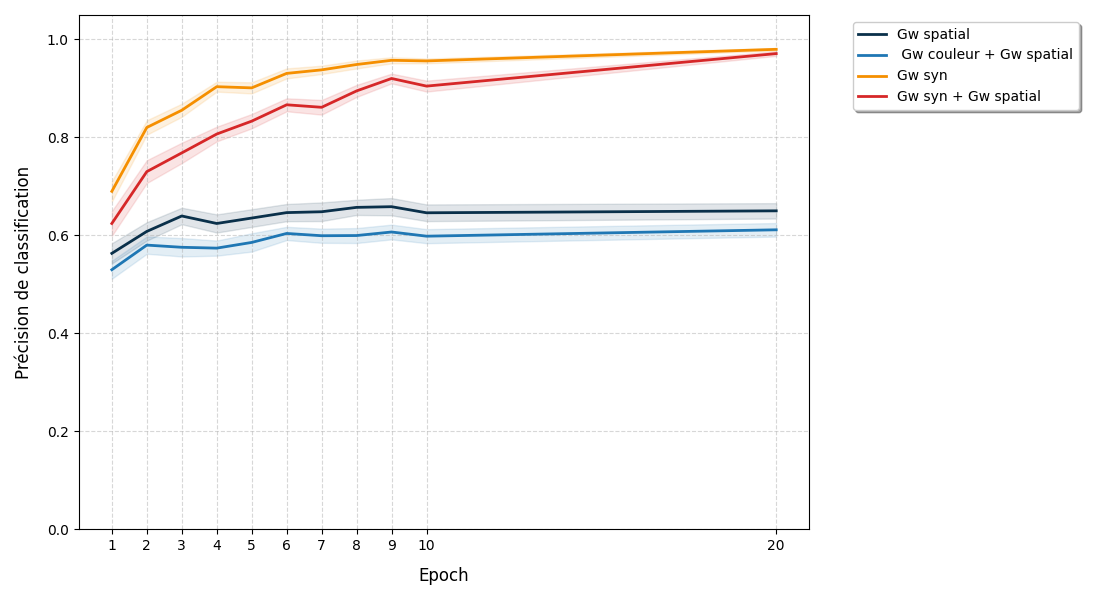

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# Import indispensable pour forcer les entiers sur l'axe
from matplotlib.ticker import MaxNLocator

DISPLAY_CONFIG = {
    'z_spatial': True,
    'z_couleur': False,
    'z_vision_2': True,
    'z_syn': True,
    'z_syn_fusion': True,
}

history = r[0:11]

keys = sorted([list(epoch_dict.keys())[0] for epoch_dict in history])

# On ajoute une clé 'label' pour contrôler le texte de la légende de chaque élément
style_config = {
    'z_spatial': {'color': '#0a304a', 'label': 'Gw spatial'},
    'z_couleur': {'color': '#39803f', 'label': 'Gw couleur'},
    'z_vision_2': {'color': '#1f77b4', 'label': 'Gw couleur + Gw spatial'},
    'z_syn': {'color': '#f58f00', 'label': 'Gw syn'},
    'z_syn_fusion': {'color': '#d62728', 'label': 'Gw syn + Gw spatial'}
}

plt.figure(figsize=(11, 6))
for key, should_display in DISPLAY_CONFIG.items():
    if should_display:
        means = []
        cis = []
        for epoch_dict in history:
            epoch_num = list(epoch_dict.keys())[0]
            data = epoch_dict[epoch_num][key]
            means.append(data['mean'])
            cis.append(data['ci_95'])
        means = np.array(means)
        cis = np.array(cis)

        color = style_config[key]['color']
        custom_label = style_config[key]['label']

        plt.plot(keys, means, label=custom_label,
                 color=color, linewidth=2, markersize=6)
        plt.fill_between(keys, means - cis, means + cis,
                         color=color, alpha=0.12)

plt.xlabel("Epoch", fontsize=12, labelpad=10)
plt.ylabel("Précision de classification", fontsize=12, labelpad=10)

ax = plt.gca()
plt.xticks(keys)                    # ← une valeur de tick par entrée dans keys
plt.ylim(0, 1.05)                   # ← 5% de marge au-dessus de 1

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, shadow=True)
plt.tight_layout()
plt.show()

In [ ]:
plt.savefig('/home/lucas/gwsyn/images/evo_3mod_basic_s126.png')